In [1]:
#%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import firtez_dz as frz
from astropy.io import fits
from matplotlib.colors import CenteredNorm, TwoSlopeNorm
import muram as mio

In [2]:
plt.rc('text', usetex = False)

## load data

In [3]:
slice = fits.open('/dat/xenosh/muram_plage_pore/slice/z795.fits')[0].data
#T, vx, vy, vz, bx, by, bz

In [4]:
muramdir = '/dat/milic/MURaM_400G_plage_pore/3D/'

In [19]:
iter = 26000

In [20]:
test = mio.MuramSnap(muramdir,iter)

In [6]:
test.tau.shape

(1056, 1536, 1536)

In [7]:
a = np.copy(test.tau[795,:,:])

In [7]:
Ic = np.memmap(muramdir[:-3]+'2D/Pore_10Mm_6x6km_res_Bz400G_Iout_bref_012000_to_044450.dat',dtype=np.float32,mode='r',shape=(650,1536,1536))

In [6]:
test.Temp.shape

(1056, 1536, 1536)

In [7]:
T = mio.MuramCube(muramdir,iter,'Temp')

In [8]:
T.shape

(1056, 1536, 1536)

In [9]:
T = T.transpose(1,2,0)

In [10]:
T.shape

(1536, 1536, 1056)

In [18]:
T = T[:,:,750:850]

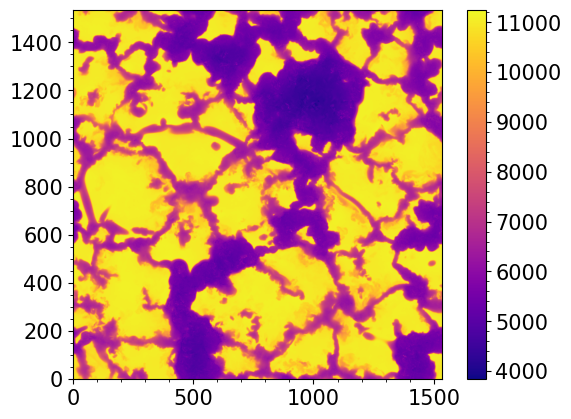

In [38]:
plt.imshow(T[:,:,40].T,origin='lower',cmap='plasma')
plt.colorbar()

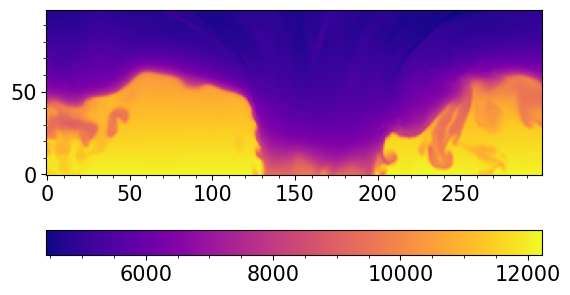

In [40]:
plt.imshow(T[800:1100,768,:].T,origin='lower',cmap='plasma')
plt.colorbar(orientation='horizontal')

In [19]:
Bz = mio.MuramCube(muramdir, iter, 'Bx')
Bz = Bz.transpose(1,2,0)
Bz = Bz[:,:,750:850]
Bz = Bz * np.sqrt(4 * np.pi)

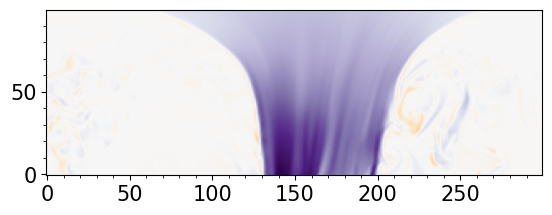

In [30]:
plt.imshow(Bz[800:1100,768,:].T,origin='lower',cmap='PuOr',norm=CenteredNorm())

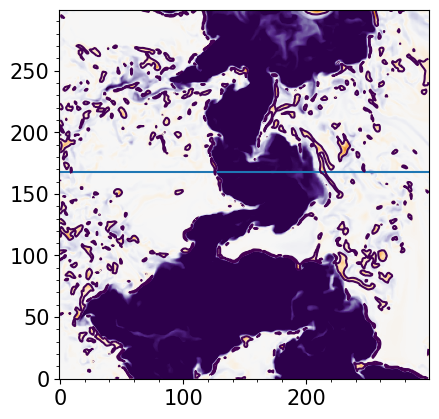

In [35]:
plt.imshow(Bz[800:1100,600:900,40].T,origin='lower',cmap='PuOr',vmin=-1500,vmax=1500)
plt.axhline(168)
plt.contour(Bz[800:1100,600:900,40].T,levels=[-150])

In [8]:
(26000-12000)/500

28.0

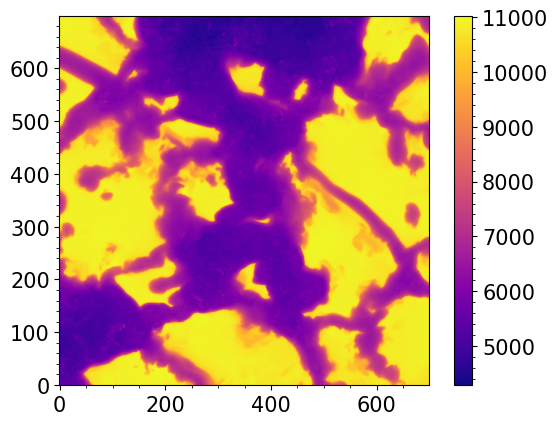

In [39]:
t = 28
plt.imshow(slice[t,0,600:1300,400:1100].T,origin='lower',cmap='plasma')
plt.colorbar()

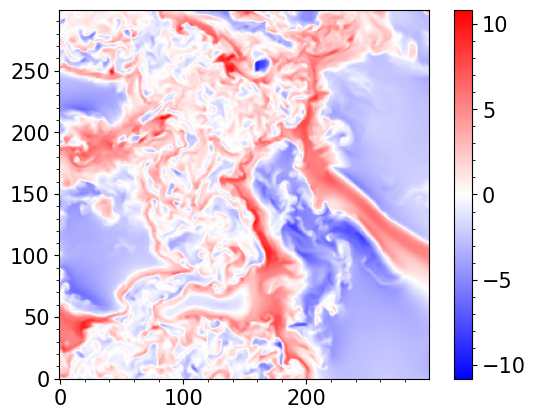

In [34]:
t = 28
plt.imshow(-slice[t,3,850:1150,650:950].T/1e5,origin='lower',cmap='bwr',norm=CenteredNorm())
plt.colorbar()

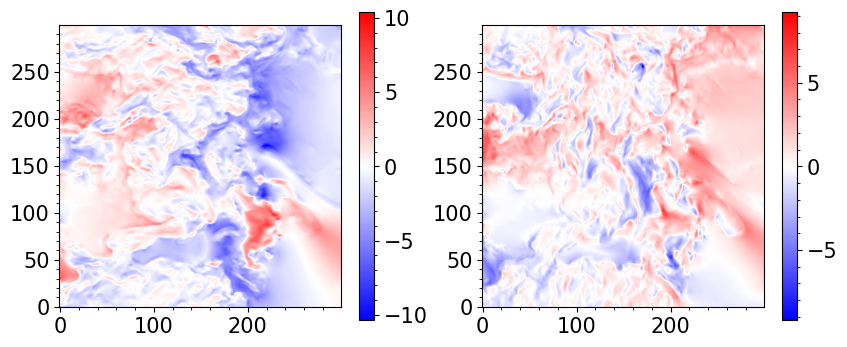

In [33]:
t = 28
plt.figure(figsize=(10,4))
plt.subplot(121)
plt.imshow(slice[t,1,850:1150,650:950].T/1e5,origin='lower',cmap='bwr',norm=CenteredNorm())
plt.colorbar()
plt.subplot(122)
plt.imshow(slice[t,2,850:1150,650:950].T/1e5,origin='lower',cmap='bwr',norm=CenteredNorm())
plt.colorbar()

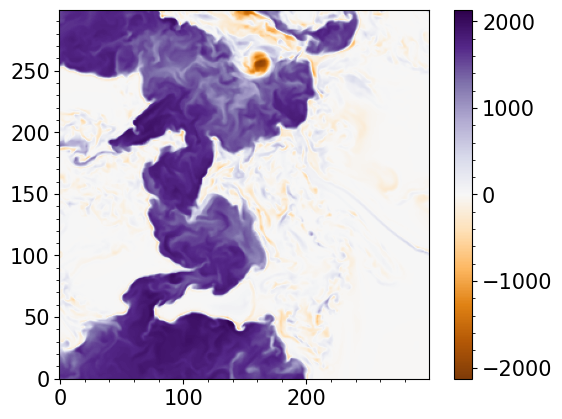

In [26]:
plt.imshow(slice[t,6,850:1150,650:950].T*np.sqrt(4*np.pi),origin='lower',cmap='PuOr',norm=CenteredNorm())
plt.colorbar()

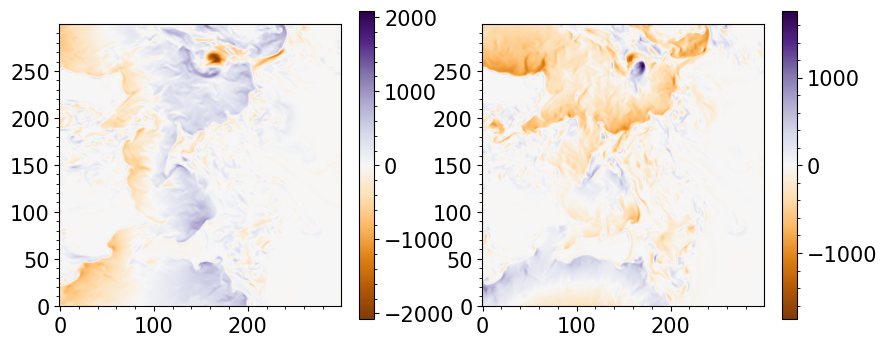

In [28]:
t = 28
plt.figure(figsize=(10,4))
plt.subplot(121)
plt.imshow(slice[t,4,850:1150,650:950].T*np.sqrt(4*np.pi),origin='lower',cmap='PuOr',norm=CenteredNorm())
plt.colorbar()
plt.subplot(122)
plt.imshow(slice[t,5,850:1150,650:950].T*np.sqrt(4*np.pi),origin='lower',cmap='PuOr',norm=CenteredNorm())
plt.colorbar()

## current (TO DO)

In [ ]:
# Constants
mu0 = 4*np.pi*1e-7  # Vacuum permeability in N/A^2

# Grid spacing in meters (replace with actual solar pixel scale)
dx = 6.5e3  #  km in x-direction
dy = 6.5e3  #  km in y-direction

# Compute derivatives using central differences
dBy_dx = (np.roll(slice[t,5,:,:], -1, axis=0) - np.roll(slice[t,5,:,:], 1, axis=0))*np.sqrt(4*np.pi) / (2*dx)
dBx_dy = (np.roll(slice[t,4,:,:], -1, axis=1) - np.roll(slice[t,4,:,:], 1, axis=1))*np.sqrt(4*np.pi) / (2*dy)

# Vertical current density Jz
Jz = (dBy_dx - dBx_dy) / mu0  # Units: A/m^2

# Optionally, set boundaries to zero (since np.roll wraps around)
Jz[0, :] = 0
Jz[-1, :] = 0
Jz[:, 0] = 0
Jz[:, -1] = 0

# Total vertical current through the plane
I_total = np.sum(Jz) * dx * dy  # Units: A
print("Total vertical current I_total:", I_total, "A")

Total vertical current I_total: 5383326338615.987 A


## vortex flow

$\vec \omega = \nabla \times \vec v$ \
\
$\nabla \times \vec v = (\frac{\partial v_z}{\partial y} - \frac{\partial v_y}{\partial z}) \hat i + (\frac{\partial v_x}{\partial z} - \frac{\partial v_z}{\partial x}) \hat j + (\frac{\partial v_y}{\partial x} - \frac{\partial v_x}{\partial y}) \hat k$ \
\
$\omega_H = \sqrt{\omega_x^2 + \omega_y^2}$ 


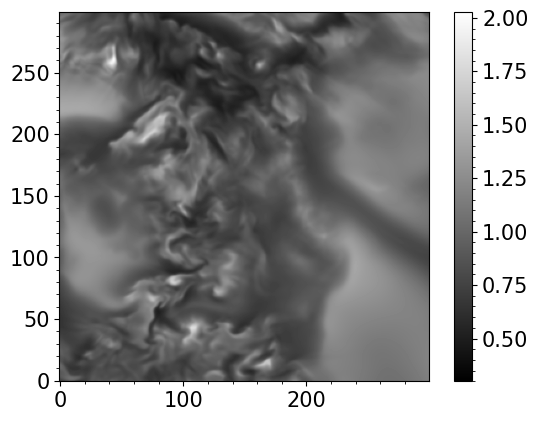

In [17]:
plt.imshow(Ic[280,850:1150,650:950].T/np.mean(Ic[280,200:600,600:1000]),origin='lower',cmap='gray',vmin=0.3)
plt.colorbar()

In [21]:
vx = np.copy(test.vy[750:850,850:1150,650:950])
vy = np.copy(test.vz[750:850,850:1150,650:950])
vz = np.copy(test.vx[750:850,850:1150,650:950])

In [22]:
vx = vx.transpose(1,2,0)
vy = vy.transpose(1,2,0)
vz = vz.transpose(1,2,0)

In [23]:
wx = np.gradient(vz/1e5,6.5,axis=1) - np.gradient(vy/1e5,6.5,axis=2)

In [24]:
wy = np.gradient(vx/1e5,6.5,axis=2) - np.gradient(vz/1e5,6.5,axis=0)

In [25]:
wz = np.gradient(vy/1e5,6.5,axis=0) - np.gradient(vx/1e5,6.5,axis=1)

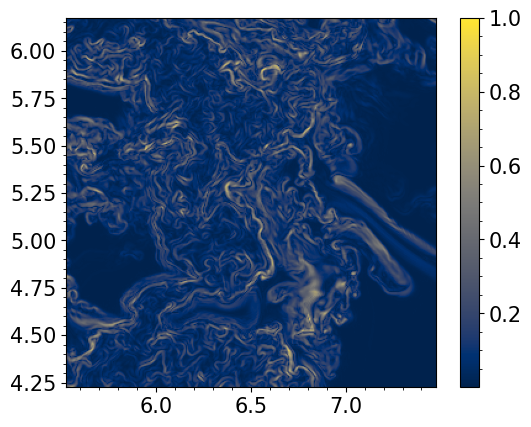

In [35]:
plt.imshow(np.sqrt(wx[:,:,45]**2+wy[:,:,45]**2).T,origin='lower',cmap='cividis',vmax=1,extent=[850*6.5/1e3,1150*6.5/1e3,650*6.5/1e3,950*6.5/1e3])
plt.colorbar()
#plt.xlim([6,7])
#plt.ylim([4.5,5.5])

In [29]:
4500/6.5

692.3076923076923

In [30]:
1000/6.5

153.84615384615384

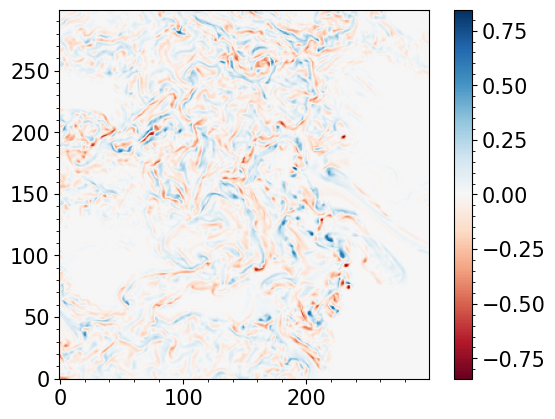

In [21]:
plt.imshow(wz[:,:,45].T,origin='lower',cmap='RdBu',norm=CenteredNorm())
plt.colorbar()

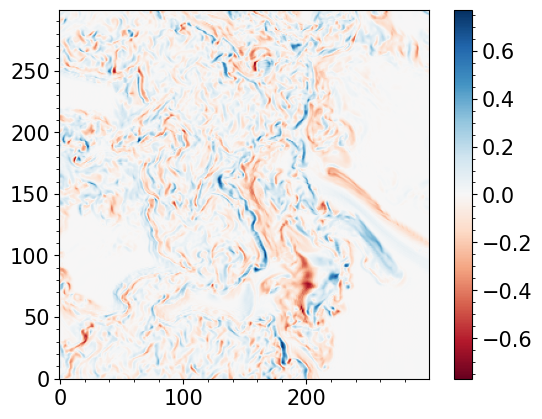

In [12]:
plt.imshow(wy[:,:,45].T,origin='lower',cmap='RdBu',norm=CenteredNorm())
plt.colorbar()

In [13]:
1536/2*6

4608.0

In [27]:
95*6-680

-110

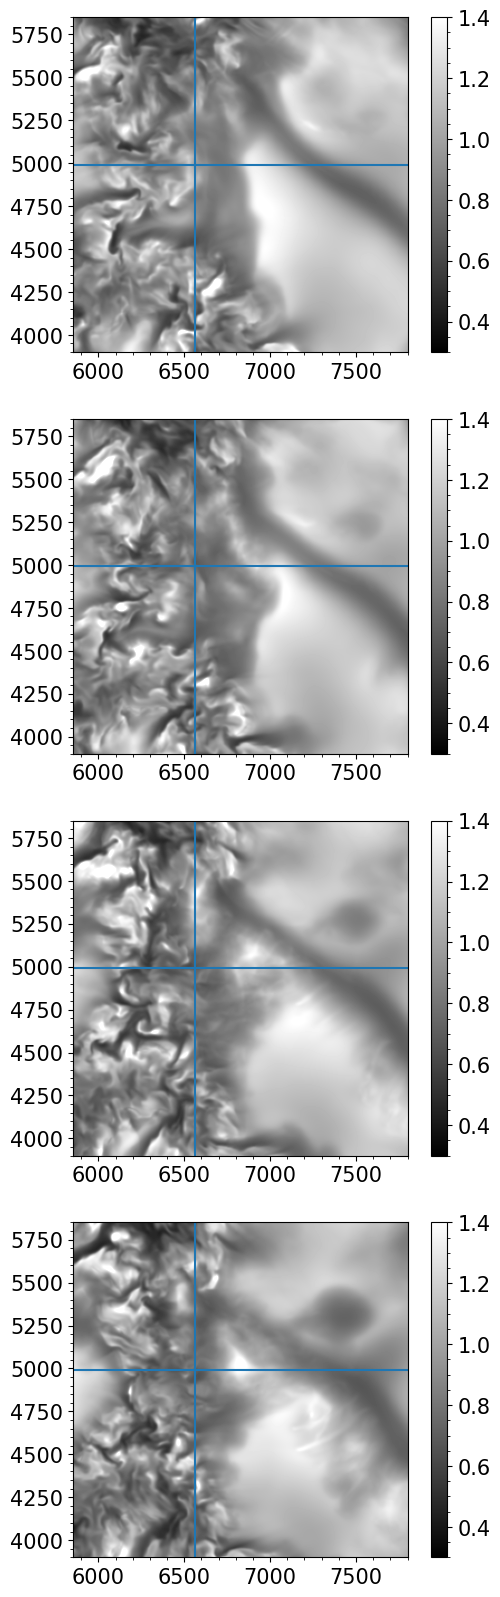

In [28]:
x1 = 900
x2 = x1 + 300
y1 = 600
y2 = y1 + 300

plt.figure(figsize=(6,20))
plt.subplot(411)
plt.imshow(Ic[240,x1:x2,y1:y2].T/np.mean(Ic[280,200:600,600:1000]),origin='lower',cmap='gray',vmin=0.3,extent=[x1*6.5,x2*6.5,y1*6.5,y2*6.5],vmax=1.4)
plt.colorbar()
#plt.title('Ic')
plt.axhline(768*6.5)
plt.axvline(1010*6.5)
plt.subplot(412)
plt.imshow(Ic[280,x1:x2,y1:y2].T/np.mean(Ic[280,200:600,600:1000]),origin='lower',cmap='gray',vmin=0.3,extent=[x1*6.5,x2*6.5,y1*6.5,y2*6.5],vmax=1.4)
plt.colorbar()
#plt.title('Ic')
plt.axhline(768*6.5)
plt.axvline(1010*6.5)
plt.subplot(413)
plt.imshow(Ic[320,x1:x2,y1:y2].T/np.mean(Ic[280,200:600,600:1000]),origin='lower',cmap='gray',vmin=0.3,extent=[x1*6.5,x2*6.5,y1*6.5,y2*6.5],vmax=1.4)
plt.colorbar()
#plt.title('Ic')
plt.axhline(768*6.5)
plt.axvline(1010*6.5)
plt.subplot(414)
plt.imshow(Ic[360,x1:x2,y1:y2].T/np.mean(Ic[280,200:600,600:1000]),origin='lower',cmap='gray',vmin=0.3,extent=[x1*6.5,x2*6.5,y1*6.5,y2*6.5],vmax=1.4)
plt.colorbar()
#plt.title('Ic')
plt.axhline(768*6.5)
plt.axvline(1010*6.5)

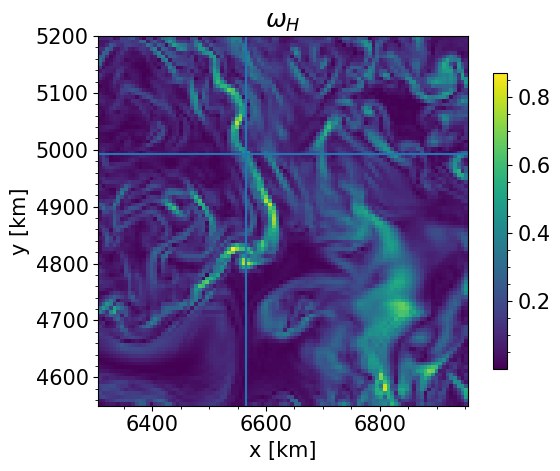

In [13]:
plt.imshow(np.sqrt(wx[120:220,50:150,45]**2 + wy[120:220,50:150,45]**2).T,origin='lower',extent=[970*6.5,1070*6.5,700*6.5,800*6.5])
plt.colorbar(shrink=0.8)
plt.title(r'$\omega_H$')
plt.xlabel('x [km]')
plt.ylabel('y [km]')
plt.axhline(768*6.5)
plt.axvline(1010*6.5)

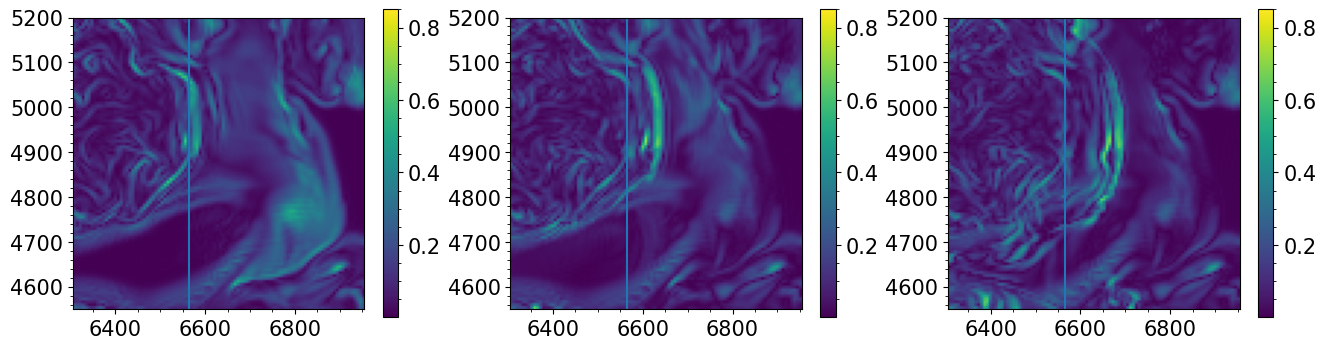

In [ ]:
#iter = 24000
plt.figure(figsize=(16,5))
plt.subplot(131)
plt.imshow(np.sqrt(wx[120:220,50:150,45]**2 + wy[120:220,50:150,45]**2).T,origin='lower',extent=[970*6.5,1070*6.5,700*6.5,800*6.5],vmax=0.85)
plt.colorbar(shrink=0.8)
plt.axvline(1010*6.5)
plt.subplot(132)
plt.imshow(np.sqrt(wx[120:220,50:150,45]**2 + wy[120:220,50:150,60]**2).T,origin='lower',extent=[970*6.5,1070*6.5,700*6.5,800*6.5],vmax=0.85)
plt.colorbar(shrink=0.8)
plt.axvline(1010*6.5)
plt.subplot(133)
plt.imshow(np.sqrt(wx[120:220,50:150,45]**2 + wy[120:220,50:150,75]**2).T,origin='lower',extent=[970*6.5,1070*6.5,700*6.5,800*6.5],vmax=0.85)
plt.colorbar(shrink=0.8)
plt.axvline(1010*6.5)

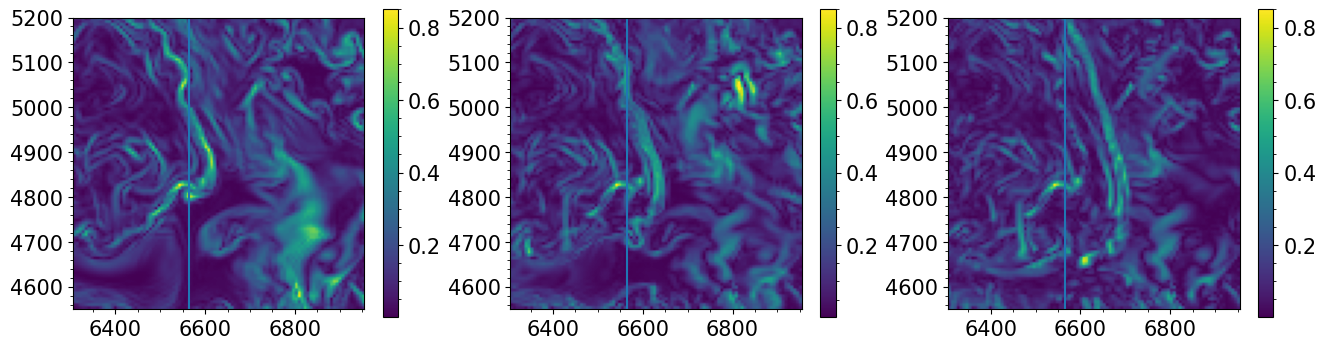

In [ ]:
#iter = 26000
plt.figure(figsize=(16,5))
plt.subplot(131)
plt.imshow(np.sqrt(wx[120:220,50:150,45]**2 + wy[120:220,50:150,45]**2).T,origin='lower',extent=[970*6.5,1070*6.5,700*6.5,800*6.5],vmax=0.85)
plt.colorbar(shrink=0.8)
plt.axvline(1010*6.5)
plt.subplot(132)
plt.imshow(np.sqrt(wx[120:220,50:150,45]**2 + wy[120:220,50:150,60]**2).T,origin='lower',extent=[970*6.5,1070*6.5,700*6.5,800*6.5],vmax=0.85)
plt.colorbar(shrink=0.8)
plt.axvline(1010*6.5)
plt.subplot(133)
plt.imshow(np.sqrt(wx[120:220,50:150,45]**2 + wy[120:220,50:150,75]**2).T,origin='lower',extent=[970*6.5,1070*6.5,700*6.5,800*6.5],vmax=0.85)
plt.colorbar(shrink=0.8)
plt.axvline(1010*6.5)

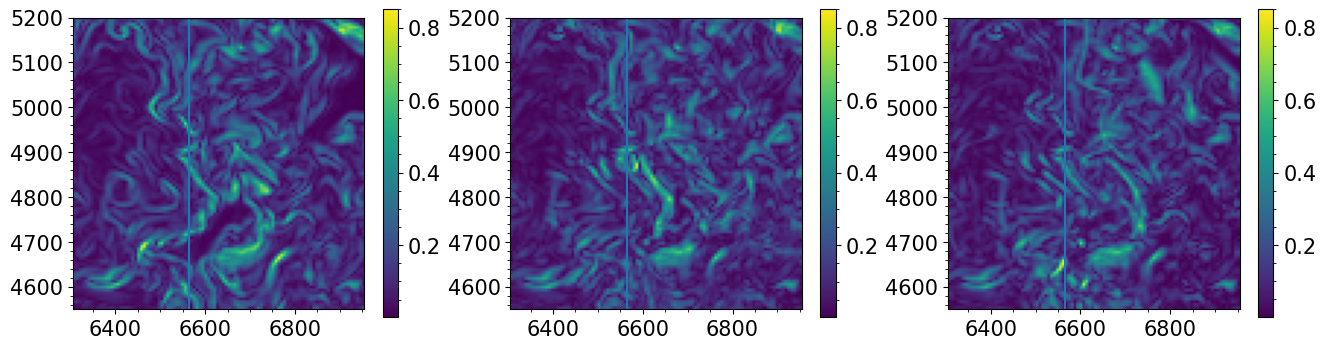

In [59]:
#iter = 28000
plt.figure(figsize=(16,5))
plt.subplot(131)
plt.imshow(np.sqrt(wx[120:220,50:150,45]**2 + wy[120:220,50:150,45]**2).T,origin='lower',extent=[970*6.5,1070*6.5,700*6.5,800*6.5],vmax=0.85)
plt.colorbar(shrink=0.8)
plt.axvline(1010*6.5)
plt.subplot(132)
plt.imshow(np.sqrt(wx[120:220,50:150,45]**2 + wy[120:220,50:150,60]**2).T,origin='lower',extent=[970*6.5,1070*6.5,700*6.5,800*6.5],vmax=0.85)
plt.colorbar(shrink=0.8)
plt.axvline(1010*6.5)
plt.subplot(133)
plt.imshow(np.sqrt(wx[120:220,50:150,45]**2 + wy[120:220,50:150,75]**2).T,origin='lower',extent=[970*6.5,1070*6.5,700*6.5,800*6.5],vmax=0.85)
plt.colorbar(shrink=0.8)
plt.axvline(1010*6.5)

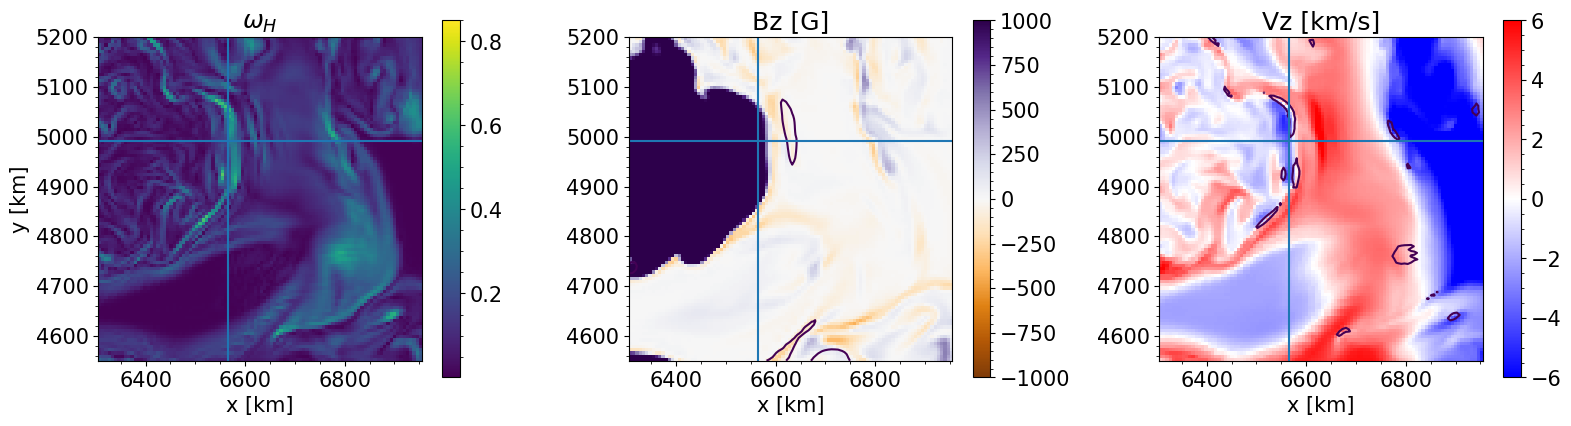

In [14]:
#t=495 24
plt.figure(figsize=(16,5))
plt.subplot(131)
plt.imshow(np.sqrt(wx[120:220,50:150,45]**2 + wy[120:220,50:150,45]**2).T,origin='lower',extent=[970*6.5,1070*6.5,700*6.5,800*6.5],vmax=0.85)
plt.colorbar(shrink=0.8)
plt.title(r'$\omega_H$')
plt.xlabel('x [km]')
plt.ylabel('y [km]')
plt.axhline(768*6.5)
plt.axvline(1010*6.5)
plt.subplot(132)
plt.imshow(slice[24,6,970:1070,700:800].T*np.sqrt(4*np.pi),origin='lower',cmap='PuOr',vmin=-1000,vmax=1000,extent=[970*6.5,1070*6.5,700*6.5,800*6.5])
plt.colorbar(shrink=0.8)
plt.contour(slice[24,3,970:1070,700:800].T/1e5,levels=['-5'],extent=[970*6.5,1070*6.5,700*6.5,800*6.5])
#plt.contour(slice[24,6,850:1150,650:950].T*np.sqrt(4*np.pi),levels=['-100'])
plt.title('Bz [G]')
plt.xlabel('x [km]')
plt.axhline(768*6.5)
plt.axvline(1010*6.5)
plt.subplot(133)
plt.imshow(-slice[24,3,970:1070,700:800].T/1e5,origin='lower',cmap='bwr',vmin=-6,vmax=6,extent=[970*6.5,1070*6.5,700*6.5,800*6.5])
plt.colorbar(shrink=0.8)
#plt.contour(slice[24,6,970:1070,700:800].T*np.sqrt(4*np.pi),levels=['-100'],extent=[970*6.5,1070*6.5,700*6.5,800*6.5])
plt.contour(np.sqrt(wx[120:220,50:150,45]**2 + wy[120:220,50:150,45]**2).T,levels=[0.4],extent=[970*6.5,1070*6.5,700*6.5,800*6.5])
plt.title('Vz [km/s]')
plt.xlabel('x [km]')
plt.axhline(768*6.5)
plt.axvline(1010*6.5)
plt.tight_layout()
#plt.savefig('vorticity.eps',bbox_inches='tight')


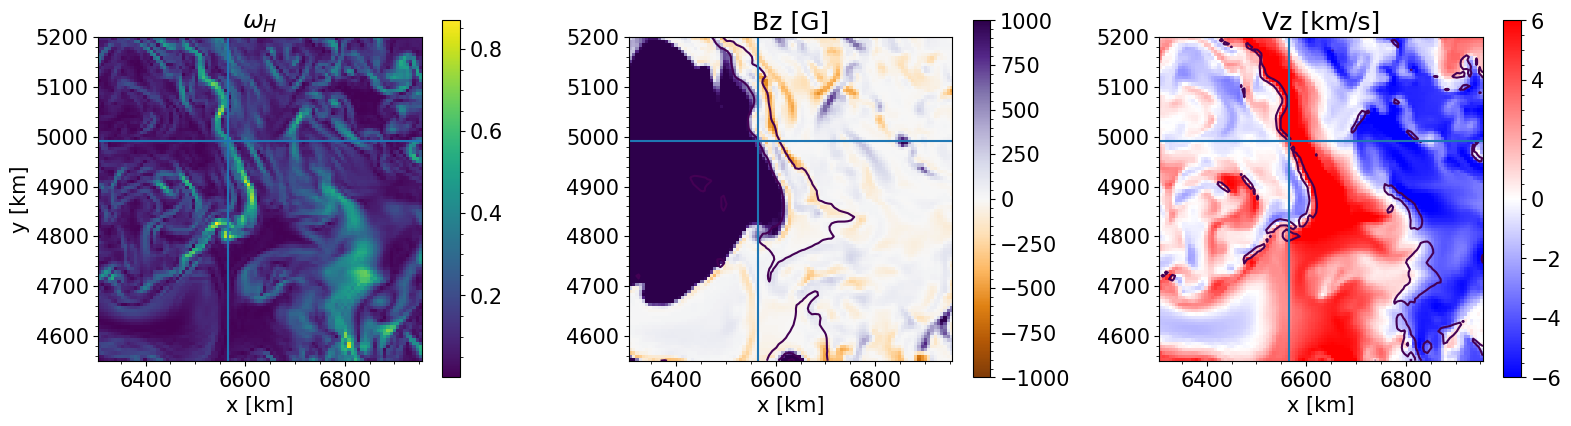

In [ ]:
#t=550 28
plt.figure(figsize=(16,5))
plt.subplot(131)
plt.imshow(np.sqrt(wx[120:220,50:150,45]**2 + wy[120:220,50:150,45]**2).T,origin='lower',extent=[970*6.5,1070*6.5,700*6.5,800*6.5])
plt.colorbar(shrink=0.8)
plt.title(r'$\omega_H$')
plt.xlabel('x [km]')
plt.ylabel('y [km]')
plt.axhline(768*6.5)
plt.axvline(1010*6.5)
plt.subplot(132)
plt.imshow(slice[28,6,970:1070,700:800].T*np.sqrt(4*np.pi),origin='lower',cmap='PuOr',vmin=-1000,vmax=1000,extent=[970*6.5,1070*6.5,700*6.5,800*6.5])
plt.colorbar(shrink=0.8)
plt.contour(slice[28,3,970:1070,700:800].T/1e5,levels=['-5'],extent=[970*6.5,1070*6.5,700*6.5,800*6.5])
#plt.contour(slice[28,6,850:1150,650:950].T*np.sqrt(4*np.pi),levels=['-100'])
plt.title('Bz [G]')
plt.xlabel('x [km]')
plt.axhline(768*6.5)
plt.axvline(1010*6.5)
plt.subplot(133)
plt.imshow(-slice[28,3,970:1070,700:800].T/1e5,origin='lower',cmap='bwr',vmin=-6,vmax=6,extent=[970*6.5,1070*6.5,700*6.5,800*6.5])
plt.colorbar(shrink=0.8)
#plt.contour(slice[28,6,970:1070,700:800].T*np.sqrt(4*np.pi),levels=['-100'],extent=[970*6.5,1070*6.5,700*6.5,800*6.5])
plt.contour(np.sqrt(wx[120:220,50:150,45]**2 + wy[120:220,50:150,45]**2).T,levels=[0.4],extent=[970*6.5,1070*6.5,700*6.5,800*6.5])
plt.title('Vz [km/s]')
plt.xlabel('x [km]')
plt.axhline(768*6.5)
plt.axvline(1010*6.5)
plt.tight_layout()
#plt.savefig('vorticity.eps',bbox_inches='tight')


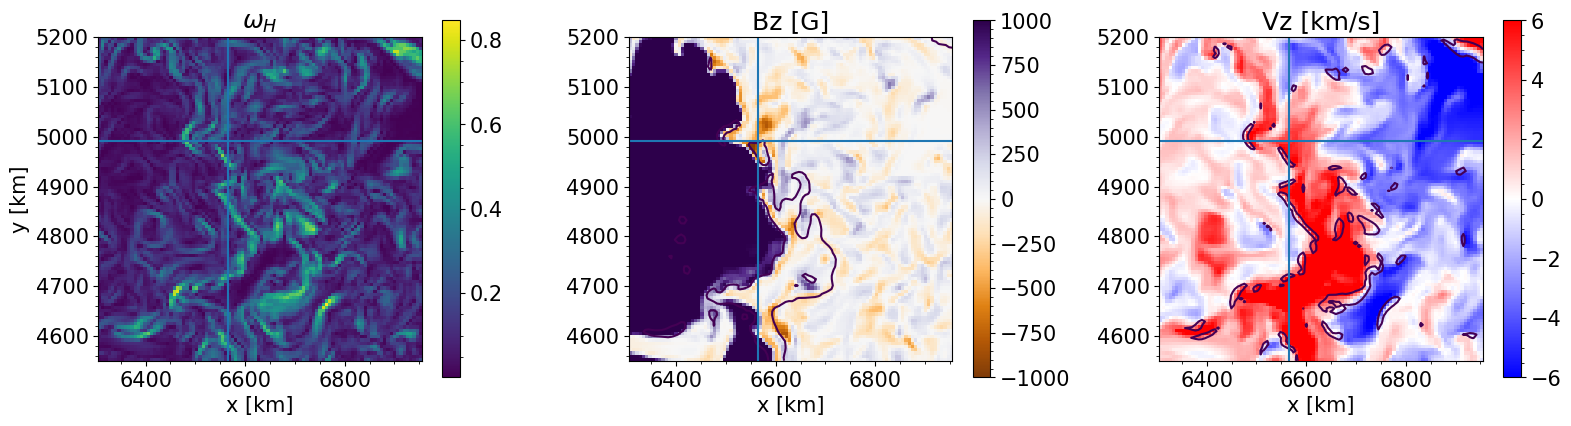

In [23]:
# t=609 32
plt.figure(figsize=(16,5))
plt.subplot(131)
plt.imshow(np.sqrt(wx[120:220,50:150,45]**2 + wy[120:220,50:150,45]**2).T,origin='lower',extent=[970*6.5,1070*6.5,700*6.5,800*6.5])
plt.colorbar(shrink=0.8)
plt.title(r'$\omega_H$')
plt.xlabel('x [km]')
plt.ylabel('y [km]')
plt.axhline(768*6.5)
plt.axvline(1010*6.5)
plt.subplot(132)
plt.imshow(slice[32,6,970:1070,700:800].T*np.sqrt(4*np.pi),origin='lower',cmap='PuOr',vmin=-1000,vmax=1000,extent=[970*6.5,1070*6.5,700*6.5,800*6.5])
plt.colorbar(shrink=0.8)
plt.contour(slice[32,3,970:1070,700:800].T/1e5,levels=['-5'],extent=[970*6.5,1070*6.5,700*6.5,800*6.5])
#plt.contour(slice[28,6,850:1150,650:950].T*np.sqrt(4*np.pi),levels=['-100'])
plt.title('Bz [G]')
plt.xlabel('x [km]')
plt.axhline(768*6.5)
plt.axvline(1010*6.5)
plt.subplot(133)
plt.imshow(-slice[32,3,970:1070,700:800].T/1e5,origin='lower',cmap='bwr',vmin=-6,vmax=6,extent=[970*6.5,1070*6.5,700*6.5,800*6.5])
plt.colorbar(shrink=0.8)
#plt.contour(slice[32,6,970:1070,700:800].T*np.sqrt(4*np.pi),levels=['-100'],extent=[970*6.5,1070*6.5,700*6.5,800*6.5])
plt.contour(np.sqrt(wx[120:220,50:150,45]**2 + wy[120:220,50:150,45]**2).T,levels=[0.4],extent=[970*6.5,1070*6.5,700*6.5,800*6.5])
plt.title('Vz [km/s]')
plt.xlabel('x [km]')
plt.axhline(768*6.5)
plt.axvline(1010*6.5)
plt.tight_layout()
#plt.savefig('vorticity.eps',bbox_inches='tight')


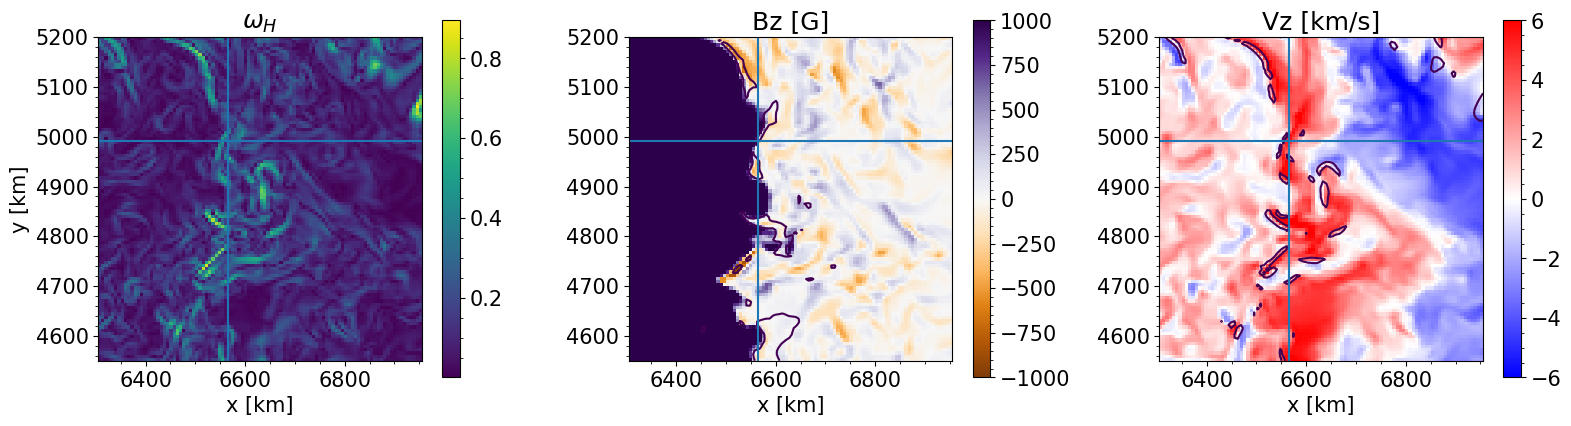

In [31]:
# t=665 36
plt.figure(figsize=(16,5))
plt.subplot(131)
plt.imshow(np.sqrt(wx[120:220,50:150,45]**2 + wy[120:220,50:150,45]**2).T,origin='lower',extent=[970*6.5,1070*6.5,700*6.5,800*6.5])
plt.colorbar(shrink=0.8)
plt.title(r'$\omega_H$')
plt.xlabel('x [km]')
plt.ylabel('y [km]')
plt.axhline(768*6.5)
plt.axvline(1010*6.5)
plt.subplot(132)
plt.imshow(slice[36,6,970:1070,700:800].T*np.sqrt(4*np.pi),origin='lower',cmap='PuOr',vmin=-1000,vmax=1000,extent=[970*6.5,1070*6.5,700*6.5,800*6.5])
plt.colorbar(shrink=0.8)
plt.contour(slice[36,3,970:1070,700:800].T/1e5,levels=['-5'],extent=[970*6.5,1070*6.5,700*6.5,800*6.5])
#plt.contour(slice[36,6,850:1150,650:950].T*np.sqrt(4*np.pi),levels=['-100'])
plt.title('Bz [G]')
plt.xlabel('x [km]')
plt.axhline(768*6.5)
plt.axvline(1010*6.5)
plt.subplot(133)
plt.imshow(-slice[36,3,970:1070,700:800].T/1e5,origin='lower',cmap='bwr',vmin=-6,vmax=6,extent=[970*6.5,1070*6.5,700*6.5,800*6.5])
plt.colorbar(shrink=0.8)
#plt.contour(slice[36,6,970:1070,700:800].T*np.sqrt(4*np.pi),levels=['-100'],extent=[970*6.5,1070*6.5,700*6.5,800*6.5])
plt.contour(np.sqrt(wx[120:220,50:150,45]**2 + wy[120:220,50:150,45]**2).T,levels=[0.4],extent=[970*6.5,1070*6.5,700*6.5,800*6.5])
plt.title('Vz [km/s]')
plt.xlabel('x [km]')
plt.axhline(768*6.5)
plt.axvline(1010*6.5)
plt.tight_layout()
#plt.savefig('vorticity.eps',bbox_inches='tight')


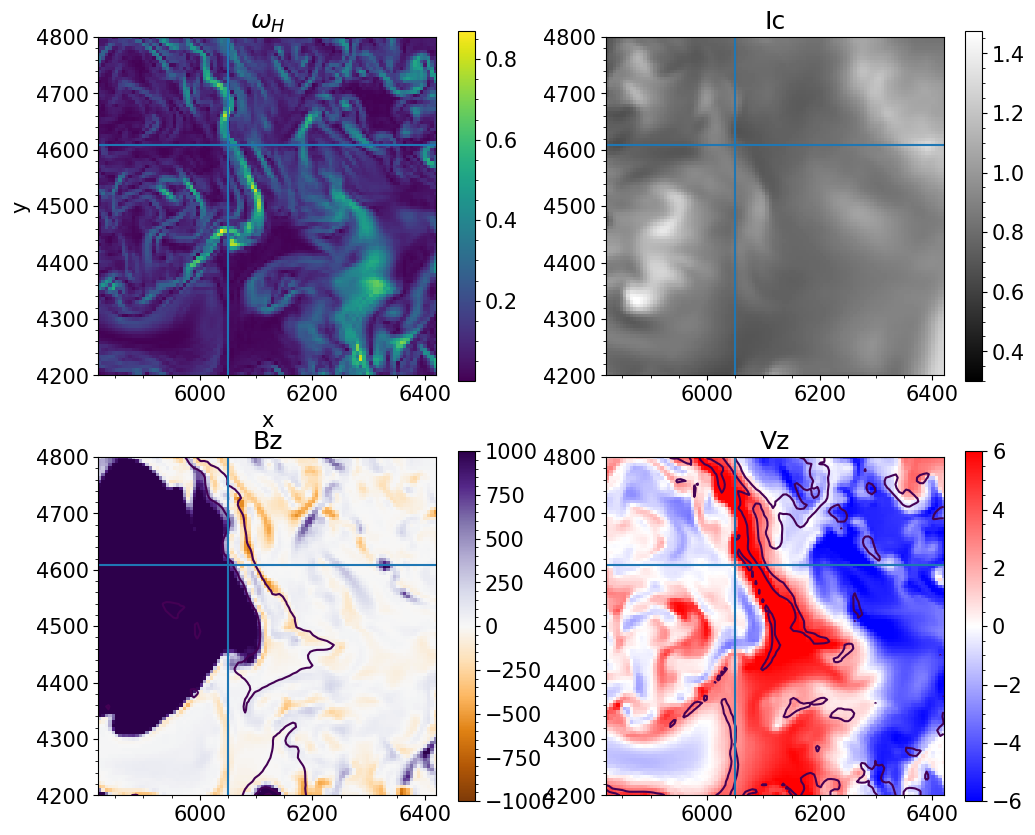

In [28]:
plt.figure(figsize=(12,10))
plt.subplot(221)
plt.imshow(np.sqrt(wx[120:220,50:150,45]**2 + wy[120:220,50:150,45]**2).T,origin='lower',extent=[970*6,1070*6,700*6,800*6])
plt.colorbar()
plt.title(r'$\omega_H$')
plt.xlabel('x')
plt.ylabel('y')
plt.axhline(768*6)
plt.axvline(6050)
plt.subplot(222)
plt.imshow(Ic[280,970:1070,700:800].T/np.mean(Ic[280,200:600,600:1000]),origin='lower',cmap='gray',vmin=0.3,extent=[970*6,1070*6,700*6,800*6])
plt.colorbar()
plt.title('Ic')
plt.axhline(768*6)
plt.axvline(6050)
plt.subplot(223)
plt.imshow(slice[28,6,970:1070,700:800].T*np.sqrt(4*np.pi),origin='lower',cmap='PuOr',vmin=-1000,vmax=1000,extent=[970*6,1070*6,700*6,800*6])
plt.colorbar()
plt.contour(slice[28,3,970:1070,700:800].T/1e5,levels=['-5'],extent=[970*6,1070*6,700*6,800*6])
#plt.contour(slice[28,6,850:1150,650:950].T*np.sqrt(4*np.pi),levels=['-100'])
plt.title('Bz')
plt.axhline(768*6)
plt.axvline(6050)
plt.subplot(224)
plt.imshow(-slice[28,3,970:1070,700:800].T/1e5,origin='lower',cmap='bwr',vmin=-6,vmax=6,extent=[970*6,1070*6,700*6,800*6])
plt.colorbar()
plt.contour(slice[28,6,970:1070,700:800].T*np.sqrt(4*np.pi),levels=['-100'],extent=[970*6,1070*6,700*6,800*6])
plt.title('Vz')
plt.axhline(768*6)
plt.axvline(6050)

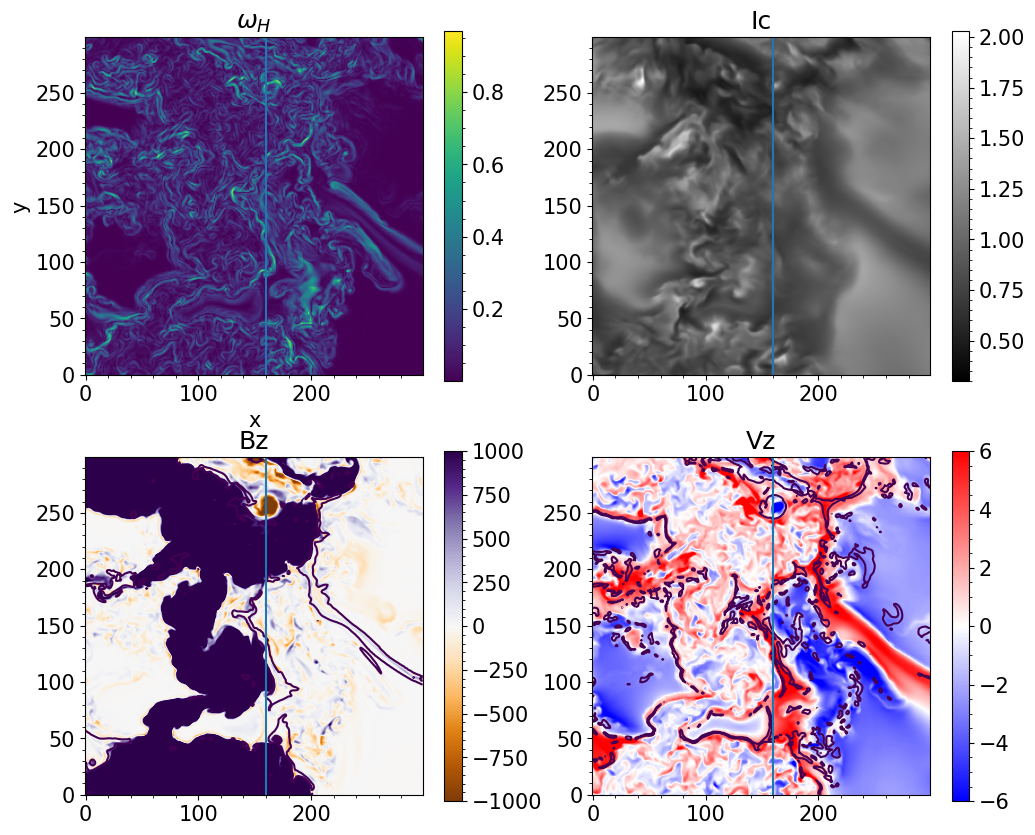

In [19]:
plt.figure(figsize=(12,10))
plt.subplot(221)
plt.imshow(np.sqrt(wx[:,:,45]**2 + wy[:,:,45]**2).T,origin='lower')
plt.colorbar()
plt.title(r'$\omega_H$')
plt.xlabel('x')
plt.ylabel('y')
plt.axvline(160)
plt.subplot(222)
plt.imshow(Ic[280,850:1150,650:950].T/np.mean(Ic[280,200:600,600:1000]),origin='lower',cmap='gray',vmin=0.3)
plt.colorbar()
plt.title('Ic')
plt.axvline(160)
plt.subplot(223)
plt.imshow(slice[28,6,850:1150,650:950].T*np.sqrt(4*np.pi),origin='lower',cmap='PuOr',vmin=-1000,vmax=1000)
plt.colorbar()
plt.contour(slice[28,3,850:1150,650:950].T/1e5,levels=['-5'])
#plt.contour(slice[28,6,850:1150,650:950].T*np.sqrt(4*np.pi),levels=['-100'])
plt.title('Bz')
plt.axvline(160)
plt.subplot(224)
plt.imshow(-slice[28,3,850:1150,650:950].T/1e5,origin='lower',cmap='bwr',vmin=-6,vmax=6)
plt.colorbar()
plt.contour(slice[28,6,850:1150,650:950].T*np.sqrt(4*np.pi),levels=['-100'])
plt.title('Vz')
plt.axvline(160)

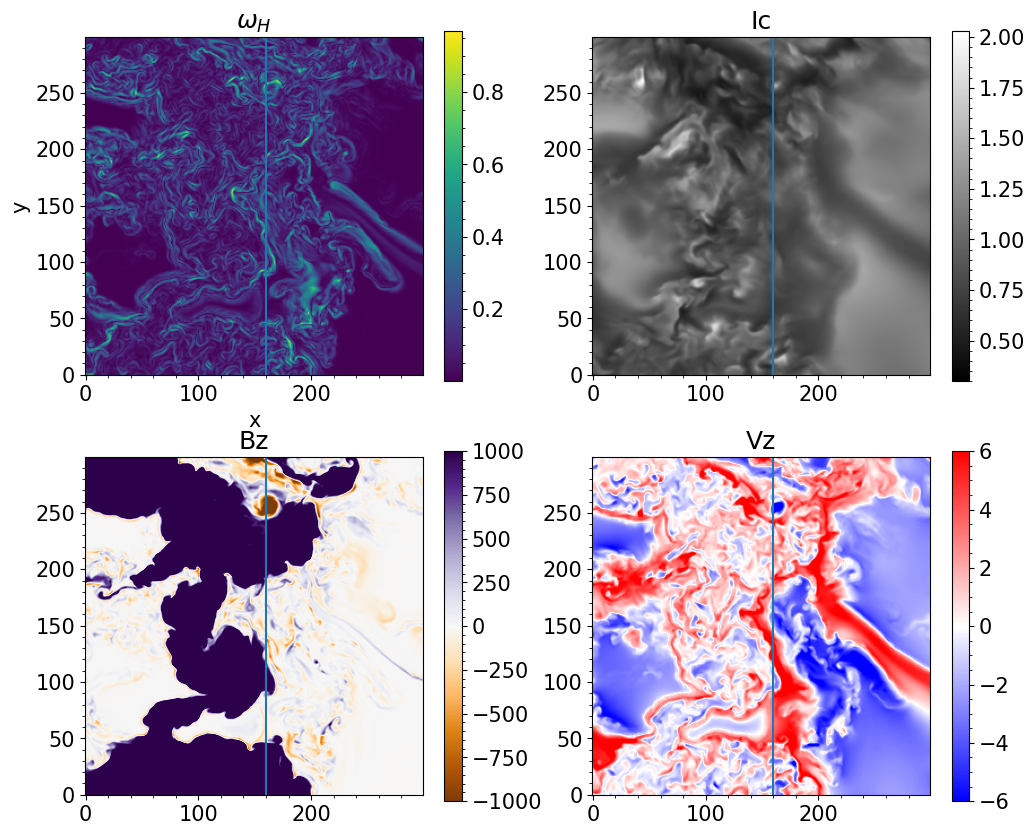

In [ ]:
plt.figure(figsize=(12,10))
plt.subplot(221)
plt.imshow(np.sqrt(wx[:,:,45]**2 + wy[:,:,45]**2).T,origin='lower')
plt.colorbar()
plt.title(r'$\omega_H$')
plt.xlabel('x')
plt.ylabel('y')
plt.axvline(160)
plt.subplot(222)
plt.imshow(Ic[280,850:1150,650:950].T/np.mean(Ic[280,200:600,600:1000]),origin='lower',cmap='gray',vmin=0.3)
plt.colorbar()
plt.title('Ic')
plt.axvline(160)
plt.subplot(223)
plt.imshow(slice[28,6,850:1150,650:950].T*np.sqrt(4*np.pi),origin='lower',cmap='PuOr',vmin=-1000,vmax=1000)
plt.colorbar()
plt.title('Bz')
plt.axvline(160)
plt.subplot(224)
plt.imshow(-slice[28,3,850:1150,650:950].T/1e5,origin='lower',cmap='bwr',vmin=-6,vmax=6)
plt.colorbar()
plt.title('Vz')
plt.axvline(160)

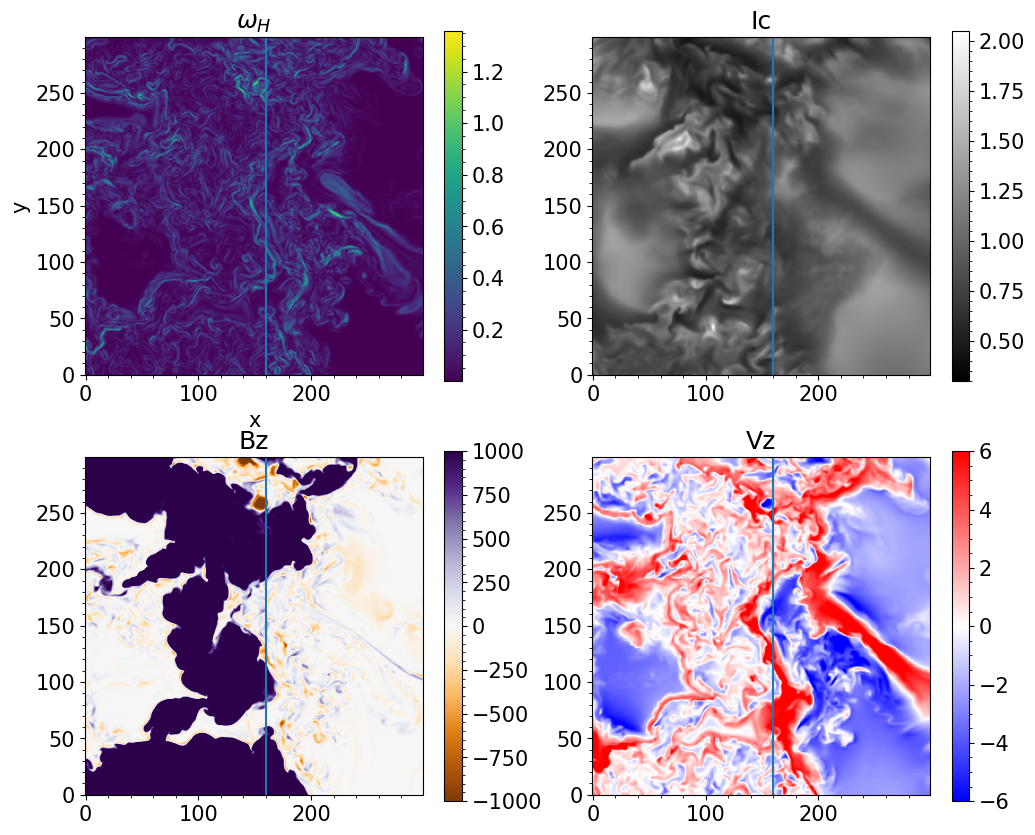

In [42]:
plt.figure(figsize=(12,10))
plt.subplot(221)
plt.imshow(np.sqrt(wx[:,:,45]**2 + wy[:,:,45]**2).T,origin='lower')
plt.colorbar()
plt.title(r'$\omega_H$')
plt.xlabel('x')
plt.ylabel('y')
plt.axvline(160)
plt.subplot(222)
plt.imshow(Ic[300,850:1150,650:950].T/np.mean(Ic[300,200:600,600:1000]),origin='lower',cmap='gray',vmin=0.3)
plt.colorbar()
plt.title('Ic')
plt.axvline(160)
plt.subplot(223)
plt.imshow(slice[30,6,850:1150,650:950].T*np.sqrt(4*np.pi),origin='lower',cmap='PuOr',vmin=-1000,vmax=1000)
plt.colorbar()
plt.title('Bz')
plt.axvline(160)
plt.subplot(224)
plt.imshow(-slice[30,3,850:1150,650:950].T/1e5,origin='lower',cmap='bwr',vmin=-6,vmax=6)
plt.colorbar()
plt.title('Vz')
plt.axvline(160)

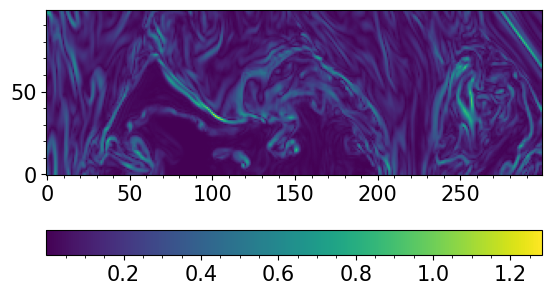

In [35]:
plt.imshow(np.sqrt(wx[160,:,:]**2 + wy[160,:,:]**2).T,origin='lower')
plt.colorbar(orientation='horizontal')

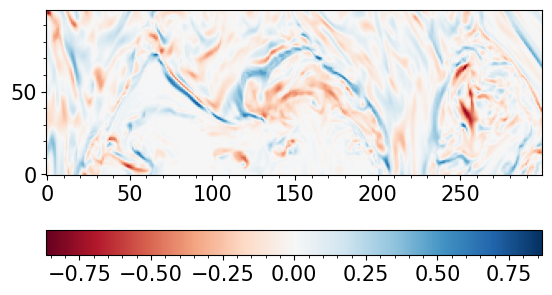

In [23]:
plt.imshow(wy[160,:,:].T,origin='lower',norm=CenteredNorm(),cmap='RdBu')
plt.colorbar(orientation='horizontal')

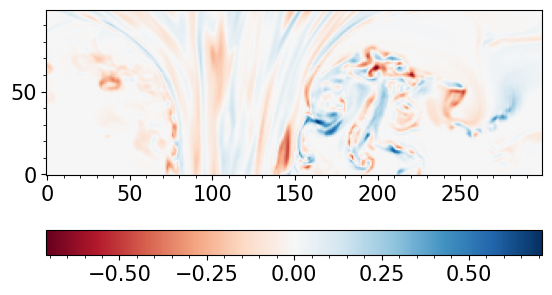

In [24]:
plt.imshow(wx[:,120,:].T,origin='lower',norm=CenteredNorm(),cmap='RdBu')
plt.colorbar(orientation='horizontal')

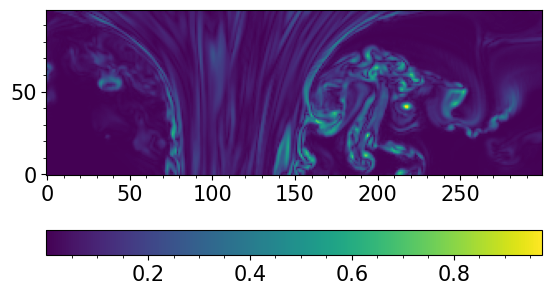

In [32]:
plt.imshow(np.sqrt(wx[:,120,:]**2 + wy[:,120,:]**2).T,origin='lower')
plt.colorbar(orientation='horizontal')